In [1]:
import pandas as pd
import pickle as pkl
from tqdm import tqdm 
import seaborn as sns
import scanpy as sc
import sys
import os 
import logging 
from omegaconf import OmegaConf, DictConfig
from hydra import initialize, compose
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np
from pathlib import Path 
import torch.nn.functional as F
import matplotlib.pyplot as plt

from labcompass.constants import DataFields
sys.path.insert(0, "../../shared_utils/")
from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn
)

logger = logging.getLogger(__name__)

In [2]:
protocol_cols = ['gm-csf_[ng_ml]', 
                 'tpo_[ng_ml]',
                 'sr1_[nm]', 
                 'um171_[nm]',
                 'um729_[µm]', 
                 'scf_[ng_ml]',
                 'butyzamide_[nm]',
                 'retinoic_acid_[µm]', 
                 'ldl_[ng_ml]', 
                 'il3_[ng_ml]', 
                 'o2_[%]',
                 'days_of_culture']

In [3]:
obs_l0 = sc.read_h5ad("../../project_folder/output/loops/data/loop0/adata_500k.h5ad").obs
obs_l1 = sc.read_h5ad("../../project_folder/output/loops/data/loop1/adata_500k_residual.h5ad").obs

In [4]:
obs_l0 = obs_l0.loc[:, protocol_cols].drop_duplicates().values.astype(float)
obs_l1 = obs_l1.loc[:, protocol_cols].drop_duplicates().values.astype(float)

In [5]:
adata_l0 = sc.AnnData(X=np.concatenate([obs_l0, obs_l1]))
adata_l0.obs = {"Loop": ["Loop0" for _ in range(len(obs_l0))] + ["Loop1" for _ in range(len(obs_l1))]}
adata_l0.var["parameter"] = protocol_cols
adata_l0.var = adata_l0.var.set_index("parameter")

In [6]:
sc.pp.log1p(adata_l0)
sc.tl.pca(adata_l0)
sc.pp.neighbors(adata_l0)
sc.tl.umap(adata_l0)

## Compute the decrease of uncertainty of forward model for subsequent opt

In [7]:
def uncertainty_quantification(
    forward_model,
    base_cfg,
    X_candidates, 
    target_cell_types, 
    n_noise_samples,
    n_populations, 
    cell_type_column, 
    classes):

    # Collct protocol columns
    protocol_columns = base_cfg["annotation"]["protocol_columns"]

    # Take cell type index 
    cell_type_index = classes.index(target_cell_types)
    ct_safe_string = target_cell_types.replace("/", ":") # cell type dir

    X_candidates = torch.from_numpy(X_candidates).float().to("cuda")
    X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
    condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
    batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}

    forward_out = forward_model.predict(
        batch_dict,
        no_grad=True,
        fix_noise=False,
        num_time_steps=100
    )
    
    y_pred = forward_out["target_prediction_data"][cell_type_column].view(X_candidates_add.shape[0],
                                                                          n_populations,
                                                                          -1,
                                                                          len(classes))  
    y_pred_softmax = F.softmax(y_pred, dim=-1)

    # Take the mean proportions 
    y_pred_mean = y_pred.mean(2)  # no_candidates x no_populations x no_cell_types 
    y_pred_softmax = y_pred_softmax.mean(2)  # no_candidates x no_populations x no_cell_types 
    print(y_pred_softmax[:, :, 21].mean())

    # Collect cell type of interest 
    y_pred_ct_std = y_pred_softmax[..., cell_type_index].std(1).detach().cpu().numpy()  # standard deviation prob cell type of interest 
    # Calculate loss
    y_target_ct = np.zeros((1, len(classes)))
    y_target_ct[:, cell_type_index] = 1.0
    y_target_ct = torch.from_numpy(y_target_ct)
    y_target_ct = y_target_ct.unsqueeze(0).to("cuda")  # 1 x 1 x no_cell_types
    
    logger.info("Compute loss function")
    loss_fn = lambda pred, target: -torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)
    with torch.no_grad():
        loss = loss_fn(y_pred_mean, y_target_ct)  # no_candidates x no_populations

    loss_std = loss.std(1).detach().cpu().numpy()  # no_candidates
    return loss_std

In [8]:
base_config_path = "../../inverse/loss_guidance/config/"
base_config_name = "run_inverse"
target_cell_types = "late_MgkPro"
n_noise_samples = 2000
n_populations = 10
cell_type_column = "cell_type" 

# Initialize paths 
with initialize(config_path=base_config_path, version_base=None):
    cfg_l0 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop0", 
                   f"loss=default",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

with initialize(config_path=base_config_path, version_base=None):
    cfg_l1 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop1",
                   f"loss=default",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

## Compute per cell type before and after unc

In [9]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l0, logger=logger)

In [10]:
# Encode classes
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs[cell_type_column].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

In [11]:
unc_l0_pred = {"cell_type": [], 
              "uncertainties": []}

for ct in classes:
    print(ct)
    unc_l0_pred["cell_type"].append(ct)
    l = []
    for _ in tqdm(range(3)):
        l.append(uncertainty_quantification(
            forward_model, 
            cfg_l0,
            adata_l0.X, 
            ct, 
            n_noise_samples,
            n_populations, 
            cell_type_column, 
            classes))
    unc_l0_pred["uncertainties"].append(l)

CD14Mono


  0%|          | 0/3 [00:00<?, ?it/s]

tensor(0.0042, device='cuda:0', grad_fn=<MeanBackward0>)


 67%|██████▋   | 2/3 [00:52<00:24, 24.58s/it]

tensor(0.0042, device='cuda:0', grad_fn=<MeanBackward0>)


...

tensor(0.0041, device='cuda:0', grad_fn=<MeanBackward0>)


 67%|██████▋   | 2/3 [00:36<00:18, 18.02s/it]

tensor(0.0042, device='cuda:0', grad_fn=<MeanBackward0>)


100%|██████████| 3/3 [00:54<00:00, 18.00s/it]

tensor(0.0041, device='cuda:0', grad_fn=<MeanBackward0>)


In [12]:
# unc_l0_pred = {key: np.stack(val, axis=0).mean(0) for key, val in unc_l0_pred.items()}

In [13]:
del forward_model
del target_prediction_model

## Predict loop1

In [14]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l1, logger=logger)

In [15]:
unc_l1_pred = {"cell_type": [], 
              "uncertainties": []}

for ct in classes:
    print(ct)
    unc_l1_pred["cell_type"].append(ct)
    l=[]
    for _ in tqdm(range(3)):
        l.append(uncertainty_quantification(
            forward_model, 
            cfg_l0,
            adata_l0.X, 
            ct, 
            n_noise_samples,
            n_populations, 
            cell_type_column,
            classes))
    unc_l1_pred["uncertainties"].append(l)

CD14Mono


 33%|███▎      | 1/3 [00:09<00:19,  9.75s/it]

tensor(0.0044, device='cuda:0', grad_fn=<MeanBackward0>)


 67%|██████▋   | 2/3 [00:19<00:09,  9.55s/it]

tensor(0.0043, device='cuda:0', grad_fn=<MeanBackward0>)


...

tensor(0.0042, device='cuda:0', grad_fn=<MeanBackward0>)


 67%|██████▋   | 2/3 [00:18<00:09,  9.48s/it]

tensor(0.0045, device='cuda:0', grad_fn=<MeanBackward0>)


100%|██████████| 3/3 [00:28<00:00,  9.48s/it]

tensor(0.0042, device='cuda:0', grad_fn=<MeanBackward0>)


In [16]:
# unc_l1_pred = {key: np.stack(val, axis=0).mean(0) for key, val in unc_l1_pred.items()}

In [17]:
del forward_model
del target_prediction_model

In [18]:
with open("./unc_l0_pred.pkl", "wb") as file:
    pkl.dump(unc_l0_pred, file)

with open("./unc_l1_pred.pkl", "wb") as file:
    pkl.dump(unc_l1_pred, file)

## Load dumps

In [19]:
with open("./unc_l0_pred.pkl", "rb") as file:
    unc_l0_pred = pkl.load(file)

with open("./unc_l1_pred.pkl", "rb") as file:
    unc_l1_pred = pkl.load(file)

In [20]:
unc_l0_pred["uncertainties"] = np.array([np.stack(arr, axis=0).mean(0).mean() for arr in unc_l0_pred["uncertainties"]])

In [21]:
unc_l1_pred["uncertainties"] = np.array([np.stack(arr, axis=0).mean(0).mean() for arr in unc_l1_pred["uncertainties"]])

In [22]:
deltas = unc_l0_pred["uncertainties"] - unc_l1_pred["uncertainties"]

In [23]:
unc_l1_pred["deltas"] = deltas
unc_l1_pred = pd.DataFrame(unc_l1_pred)

<Axes: xlabel='deltas', ylabel='cell_type'>

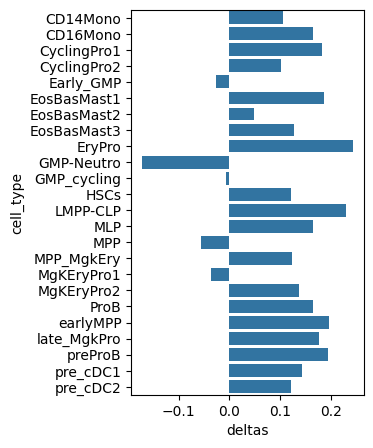

In [24]:
plt.figure(figsize=(3,5))
sns.barplot(unc_l1_pred, y="cell_type", x="deltas")

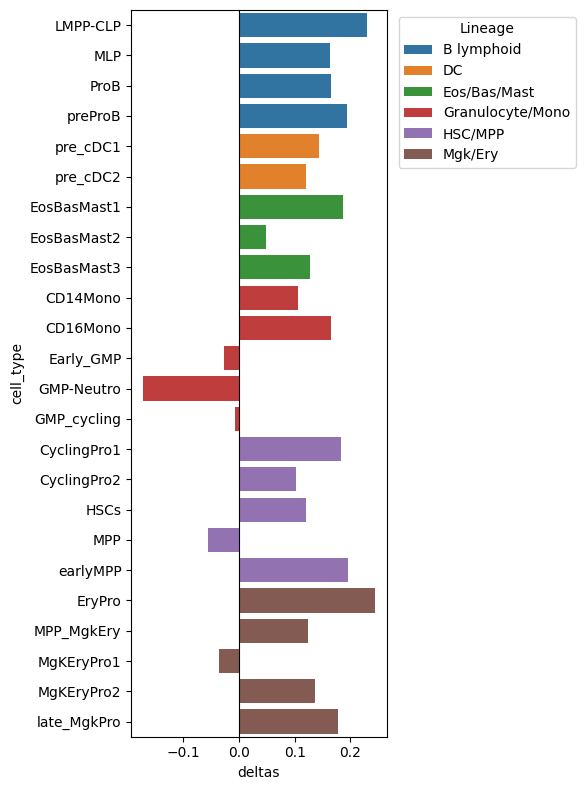

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Map each cell_type to its lineage
lineage_map = {
    "HSCs": "HSC/MPP",
    "MPP": "HSC/MPP",
    "earlyMPP": "HSC/MPP",
    "CyclingPro1": "HSC/MPP",
    "CyclingPro2": "HSC/MPP",

    "LMPP-CLP": "B lymphoid",
    "MLP": "B lymphoid",
    "ProB": "B lymphoid",
    "preProB": "B lymphoid",

    "pre_cDC1": "DC",
    "pre_cDC2": "DC",

    "EosBasMast1": "Eos/Bas/Mast",
    "EosBasMast2": "Eos/Bas/Mast",
    "EosBasMast3": "Eos/Bas/Mast",

    "CD14Mono": "Granulocyte/Mono",
    "CD16Mono": "Granulocyte/Mono",
    "Early_GMP": "Granulocyte/Mono",
    "GMP-Neutro": "Granulocyte/Mono",
    "GMP_cycling": "Granulocyte/Mono",

    "EryPro": "Mgk/Ery",
    "MPP_MgkEry": "Mgk/Ery",
    "MgKEryPro1": "Mgk/Ery",
    "MgKEryPro2": "Mgk/Ery",
    "late_MgkPro": "Mgk/Ery",
}

# Order lineages the same way as the reference barplot
lineage_order = ["B lymphoid", "DC", "Eos/Bas/Mast", "Granulocyte/Mono", "HSC/MPP", "Mgk/Ery"]

df = unc_l1_pred.copy()
df["lineage"] = df["cell_type"].map(lineage_map)

# Order rows: by lineage group, then alphabetically (or by delta) within group
df["lineage"] = pd.Categorical(df["lineage"], categories=lineage_order, ordered=True)
df = df.sort_values(["lineage", "cell_type"])

# Color palette keyed by lineage
palette = dict(zip(lineage_order, sns.color_palette("tab10", len(lineage_order))))

fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(
    data=df,
    x="deltas",
    y="cell_type",
    hue="lineage",
    order=df["cell_type"],       # preserve lineage-grouped order
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(title="Lineage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [26]:
# lineage_map = {
#     "HSCs": "HSC/MPP",
#     "MPP": "HSC/MPP",
#     "earlyMPP": "HSC/MPP",
#     "CyclingPro1": "HSC/MPP",
#     "CyclingPro2": "HSC/MPP",

#     "LMPP-CLP": "B lymphoid",
#     "MLP": "B lymphoid",
#     "ProB": "B lymphoid",
#     "preProB": "B lymphoid",

#     "pre_cDC1": "DC",
#     "pre_cDC2": "DC",

#     "EosBasMast1": "Eos/Bas/Mast",
#     "EosBasMast2": "Eos/Bas/Mast",
#     "EosBasMast3": "Eos/Bas/Mast",

#     "CD14Mono": "Granulocyte/Mono",
#     "CD16Mono": "Granulocyte/Mono",
#     "Early_GMP": "Granulocyte/Mono",
#     "GMP-Neutro": "Granulocyte/Mono",
#     "GMP_cycling": "Granulocyte/Mono",

#     "EryPro": "Mgk/Ery",
#     "MPP_MgkEry": "Mgk/Ery",
#     "MgKEryPro1": "Mgk/Ery",
#     "MgKEryPro2": "Mgk/Ery",
#     "late_MgkPro": "Mgk/Ery",
# }

# lineage_order = ["B lymphoid", "DC", "Eos/Bas/Mast", "Granulocyte/Mono", "HSC/MPP", "Mgk/Ery"]

# df = unc_l1_pred.copy()
# df["lineage"] = df["cell_type"].map(lineage_map)

# # Average deltas (and uncertainties, if you want) within each lineage
# lineage_avg = (
#     df.groupby("lineage", observed=True)[["deltas", "uncertainties"]]
#     .mean()
#     .reindex(lineage_order)
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(6, 4))
# sns.barplot(
#     data=lineage_avg,
#     x="lineage",
#     y="deltas",
#     order=lineage_order,
#     ax=ax,
# )
# ax.axhline(0, color="black", linewidth=0.8)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

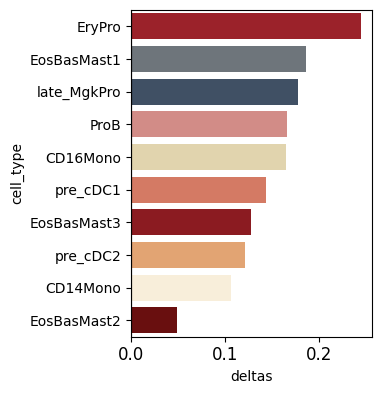

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

# Aliases to match your actual cell_type naming
color_map['pre_cDC1'] = color_map['Pre-DC1']
color_map['pre_cDC2'] = color_map['Pre-DC2']
color_map['late_MgkPro'] = color_map['MgkPro']

terminal_cell_types = {
    "B lymphoid": ["ProB"],
    "DC": ["pre_cDC1", "pre_cDC2"],
    "Eos/Bas/Mast": ["EosBasMast1", "EosBasMast2", "EosBasMast3"],
    "Granulocyte/Mono": ["CD14Mono", "CD16Mono"],
    "Mgk/Ery": ["late_MgkPro", "EryPro"],
}

lineage_order = ["B lymphoid", "DC", "Eos/Bas/Mast", "Granulocyte/Mono", "Mgk/Ery"]
ordered_cell_types = [ct for lin in lineage_order for ct in terminal_cell_types[lin]]

df_terminal = unc_l1_pred[unc_l1_pred["cell_type"].isin(ordered_cell_types)]

# Sort by delta value, highest to lowest
df_terminal = df_terminal.sort_values("deltas", ascending=False)
sorted_order = df_terminal["cell_type"].tolist()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(
    data=df_terminal,
    y="cell_type",
    x="deltas",
    order=sorted_order,
    hue="cell_type",
    palette=color_map,
    legend=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()

ax.tick_params(axis='x', labelsize=12)

# Save as SVG
fig.savefig("terminal_celltype_deltas.svg", format="svg", bbox_inches="tight")
plt.show()

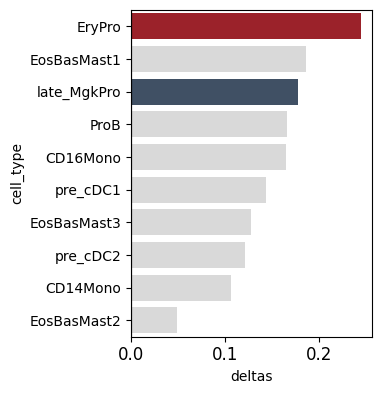

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (color_map, aliases, terminal_cell_types, lineage_order, ordered_cell_types, df_terminal, sorted_order as before)

# Build a grey-out palette: keep only EryPro and MgkPro (late_MgkPro) colored
highlight = {"EryPro", "late_MgkPro"}
grey = "#D9D9D9"  # lighter gray

plot_palette = {
    ct: (color_map[ct] if ct in highlight else grey)
    for ct in sorted_order
}

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(
    data=df_terminal,
    y="cell_type",
    x="deltas",
    order=sorted_order,
    hue="cell_type",
    palette=plot_palette,
    legend=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
ax.tick_params(axis='x', labelsize=12)

fig.savefig("terminal_celltype_deltas.svg", format="svg", bbox_inches="tight")
plt.show()